<a href="https://colab.research.google.com/github/Aswini-J/Exp3-Sobel-edge-detection-filter-using-CUDA-to-enhance-the-performance-of-image-processing-tasks./blob/main/Sobel_edge_detection_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-34bqvws8
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-34bqvws8
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-ntz3fqp0/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp22egksi1".


In [3]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [4]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [5]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File does not exist!


In [6]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [7]:
from google.colab import files
uploaded = files.upload()

Saving women.jpg to women.jpg


In [8]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('/content/women.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [9]:
pwd


'/content'

In [11]:
ls /content/women.jpg

/content/women.jpg


In [12]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('/content/women.jpg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [18]:
%%writefile sobelEdgeDetectionFilter.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>

using namespace cv;

__global__ void sobelFilter(unsigned char *srcImage, unsigned char *dstImage, unsigned int width, unsigned int height) {
int x = blockIdx.x * blockDim.x + threadIdx.x;
int y = blockIdx.y * blockDim.y + threadIdx.y;

if (x >= width || y >= height) return;

int idx = y * width + x;

if (x == 0 || y == 0 || x == width - 1 || y == height - 1) {
    dstImage[idx] = 0;
    return;
}

int Gx =
    -srcImage[(y - 1) * width + (x - 1)] + srcImage[(y - 1) * width + (x + 1)]
    -2 * srcImage[y * width + (x - 1)]     + 2 * srcImage[y * width + (x + 1)]
    -srcImage[(y + 1) * width + (x - 1)] + srcImage[(y + 1) * width + (x + 1)];

int Gy =
    -srcImage[(y - 1) * width + (x - 1)] - 2 * srcImage[(y - 1) * width + x] - srcImage[(y - 1) * width + (x + 1)]
    +srcImage[(y + 1) * width + (x - 1)] + 2 * srcImage[(y + 1) * width + x] + srcImage[(y + 1) * width + (x + 1)];

int magnitude = sqrtf((float)(Gx * Gx + Gy * Gy));

if (magnitude > 255) magnitude = 255;

dstImage[idx] = (unsigned char)magnitude;




}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {
    // Read input image
   Mat image = imread("/content/women.jpg", IMREAD_GRAYSCALE);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;
    size_t imageSize = width * height * sizeof(unsigned char);

    // Allocate host memory for output image
    unsigned char *h_outputImage = (unsigned char *)malloc(imageSize);
    if (h_outputImage == nullptr) {
        fprintf(stderr, "Failed to allocate host memory\n");
        return -1;
    }

    // Allocate device memory
    unsigned char *d_inputImage, *d_outputImage;
    checkCudaErrors(cudaMalloc(&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, imageSize));
    checkCudaErrors(cudaMemcpy(d_inputImage, image.data, imageSize, cudaMemcpyHostToDevice));

    // Define CUDA events for timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Launch kernel
    dim3 blockSize(16, 16);
    dim3 gridSize(ceil(width / 16.0), ceil(height / 16.0));

    cudaEventRecord(start);
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage, d_outputImage, width, height);
    cudaEventRecord(stop);

    // Synchronize events
    cudaEventSynchronize(stop);

    // Calculate elapsed time
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    checkCudaErrors(cudaMemcpy(h_outputImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost));

    // Write output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);
    imwrite("output_sobel.jpeg", outputImage);

    // Free memory
    free(h_outputImage);
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    // Destroy CUDA events
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    // Print elapsed time
    printf("Total time taken: %f milliseconds\n", milliseconds);

    return 0;
}


Overwriting sobelEdgeDetectionFilter.cu


In [19]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`


Package opencv4 was not found in the pkg-config search path.
Perhaps you should add the directory containing `opencv4.pc'
to the PKG_CONFIG_PATH environment variable
Package 'opencv4', required by 'virtual:world', not found
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
sobelEdgeDetectionFilter.cu:5:10: fatal error: opencv2/opencv.hpp: No such file or directory
    5 | #include <opencv2/opencv.hpp>
      |          ^~~~~~~~~~~~~~~~~~~~
compilation terminated.


In [20]:
!./sobelEdgeDetectionFilter

/bin/bash: line 1: ./sobelEdgeDetectionFilter: No such file or directory


In [22]:
import cv2
from matplotlib import pyplot as plt

output_image = cv2.imread("/content/output_sobel.jpeg", cv2.IMREAD_GRAYSCALE)

if output_image is None:
    print("Output image not created. Check CUDA run output.")
else:
    plt.imshow(output_image, cmap="gray")
    plt.title("Edge Detection Output")
    plt.axis("off")
    plt.show()

Output image not created. Check CUDA run output.


In [23]:
!apt-get update
!apt-get install -y libopencv-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-securi

In [24]:
!nvcc sobelEdgeDetectionFilter.cu -o sobelEdgeDetectionFilter `pkg-config --cflags --libs opencv4`

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [25]:
!./sobelEdgeDetectionFilter

Total time taken: 104.078850 milliseconds


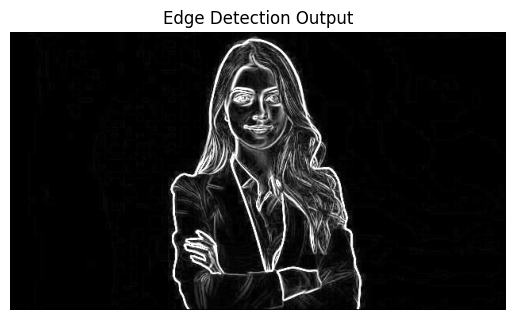

In [26]:
import cv2
from matplotlib import pyplot as plt

output_image = cv2.imread("/content/output_sobel.jpeg", cv2.IMREAD_GRAYSCALE)

if output_image is None:
    print("Output image not created.")
else:
    plt.imshow(output_image, cmap="gray")
    plt.title("Edge Detection Output")
    plt.axis("off")
    plt.show()